In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Model evaluated:
checkpoint: `attn_cue_models/word_task_standard_v07/checkpoints/epoch=3-step=67111.ckpt`   
config: `config/binaural_attn/word_task_standard_v07.yaml`

In [2]:
ls binaural_eval/human_pilot_conds/

word_task_all_co_located_v04/
word_task_deep_fc_1024_v08/
word_task_half_co_loc_v05/
word_task_half_co_loc_v06/
word_task_half_co_loc_v06_old_ckpt/
word_task_half_co_loc_v07/
word_task_half_co_loc_v08/
word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/
word_task_no_co_loc_v05/
word_task_sans_loc_only_cue_v04/
word_task_standard_v06sm_lr/
word_task_standard_v07/
word_task_standard_v08/
word_task_v08_control_no_attn/
word_task_voice_loc_cue_only_v04/


In [3]:
ls /om2/user/rphess/Auditory-Attention/binaural_eval/human_pilot_conds/

word_task_25p_loc_v07_LN_last_valid_time_no_affine/
word_task_early_only_v08/
word_task_half_co_loc_v08_70p_same/
word_task_late_only_v08/
word_task_quarter_co_loc_v08/


In [4]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
model_name = 'word_task_half_co_loc_v08'
# model_name = 'word_task_quarter_co_loc_v08'
# model_name = 'word_task_25p_loc_v07_LN_last_valid_time_no_affine'

output_paths = list(Path(f"binaural_eval/human_pilot_conds/{model_name}").glob("*.pkl"))
# output_paths = list(Path(f"/om2/user/rphess/Auditory-Attention/binaural_eval/human_pilot_conds/{model_name}").glob("*.pkl"))


stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    
    df.rename(columns={"results": "accuracy"}, inplace=True)
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')  
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)

    
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [5]:
results.shape

(1603248, 13)

In [6]:
# results.shape

In [7]:
grouped_results = results.groupby(['target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'gender_cond']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]


# grouped_results["elevation_cond"] = grouped_results.apply(lambda row: f"target {row.target_elev} distractor {row.distractor_elev}", axis=1)
grouped_results['elevation_sep'] = grouped_results.target_elev - grouped_results.distractor_elev
grouped_results['abs_elevation_sep'] = grouped_results.elevation_sep.abs()
grouped_results['elevated_source'] = grouped_results.elevation_sep.apply(lambda x: 'target' if x > 0 else 'distractor' if x < 0 else 'co-located') 

grouped_results['abs_target_azim'] = grouped_results.target_azim.abs()
grouped_results['abs_distractor_azim'] = grouped_results.distractor_azim.abs()

grouped_results['azim_delta'] = grouped_results.target_azim - grouped_results.distractor_azim
grouped_results['abs_azim_delta'] = (grouped_results.target_azim - grouped_results.distractor_azim).abs()




In [8]:
grouped_results.head()

,target_azim,target_elev,distractor_azim,distractor_elev,gender_cond,accuracy_mean,accuracy_sem,confusions_mean,confusions_sem,elevation_sep,abs_elevation_sep,elevated_source,abs_target_azim,abs_distractor_azim,azim_delta,abs_azim_delta
0,-90,-20,-90,-20,diff,0.434728,0.012483,0.129278,0.008449,0,0,co-located,90,90,0,0
1,-90,-20,-90,-20,same,0.363752,0.012114,0.213561,0.010320,0,0,co-located,90,90,0,0
2,-90,-20,-90,-10,diff,0.453739,0.012537,0.124208,0.008305,-10,10,distractor,90,90,0,0
3,-90,-20,-90,-10,same,0.378327,0.012212,0.201521,0.010101,-10,10,distractor,90,90,0,0
4,-90,-20,-90,0,diff,0.487326,0.012587,0.110266,0.007887,-20,20,distractor,90,90,0,0


In [9]:
# # with open("binaural_test_manifests/expanded_all_azim_chosen_elev_az_11_29_2023.pkl", "rb") as f:
# with open("binaural_test_manifests/match_human_pilot_conds.pkl", "rb") as f:
#     loc_dict = pickle.load(f)
# loc_df = pd.DataFrame.from_records([{'target_az':targ_loc[0], "target_elev":targ_loc[1], "distractor_az":distr_loc[0], "distractor_elev":distr_loc[1]}
#                                     for (targ_loc, distr_loc) in loc_dict.values()])
# print(loc_df.target_az.unique())
# print(loc_df.target_elev.unique())

Text(0.5, 1.0, 'Model')

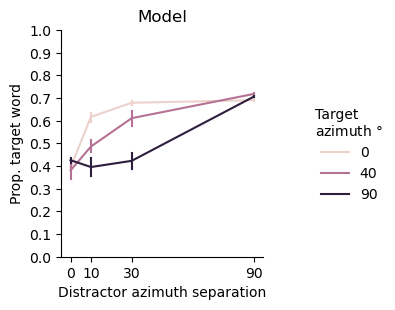

In [55]:
to_plot = grouped_results[grouped_results.target_azim.isin([0, -40, -90, 40, 90 ])].copy()
to_plot['abs_target_azim'] = to_plot.target_azim.abs()

to_plot['dist_azim_delta'] = (to_plot.target_azim - to_plot.distractor_azim).abs()

to_plot = to_plot[to_plot.dist_azim_delta.isin([0, 10, 30, 90])]
g = sns.relplot(data=to_plot, x='dist_azim_delta', y='accuracy_mean', hue="abs_target_azim",
            # errorbar=('se', 2),
            err_style='bars',
            height=3, aspect=1,
            kind='line')
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")
g.set(xticks=to_plot.dist_azim_delta.unique(), yticks=np.arange(0, 1.1, 0.1));

g._legend.set_title("Target\nazimuth $\degree$")
plt.title("Model")


In [25]:
# loc_df[(loc_df.target_elev == 0) & (loc_df.distractor_elev == 0) & (loc_df.target_az == 20) & (loc_df.distractor_az.isin([0, -10, 10, 20]))]

In [26]:
# loc_df[loc_df.target_elev.eq(0)].target_az.unique()

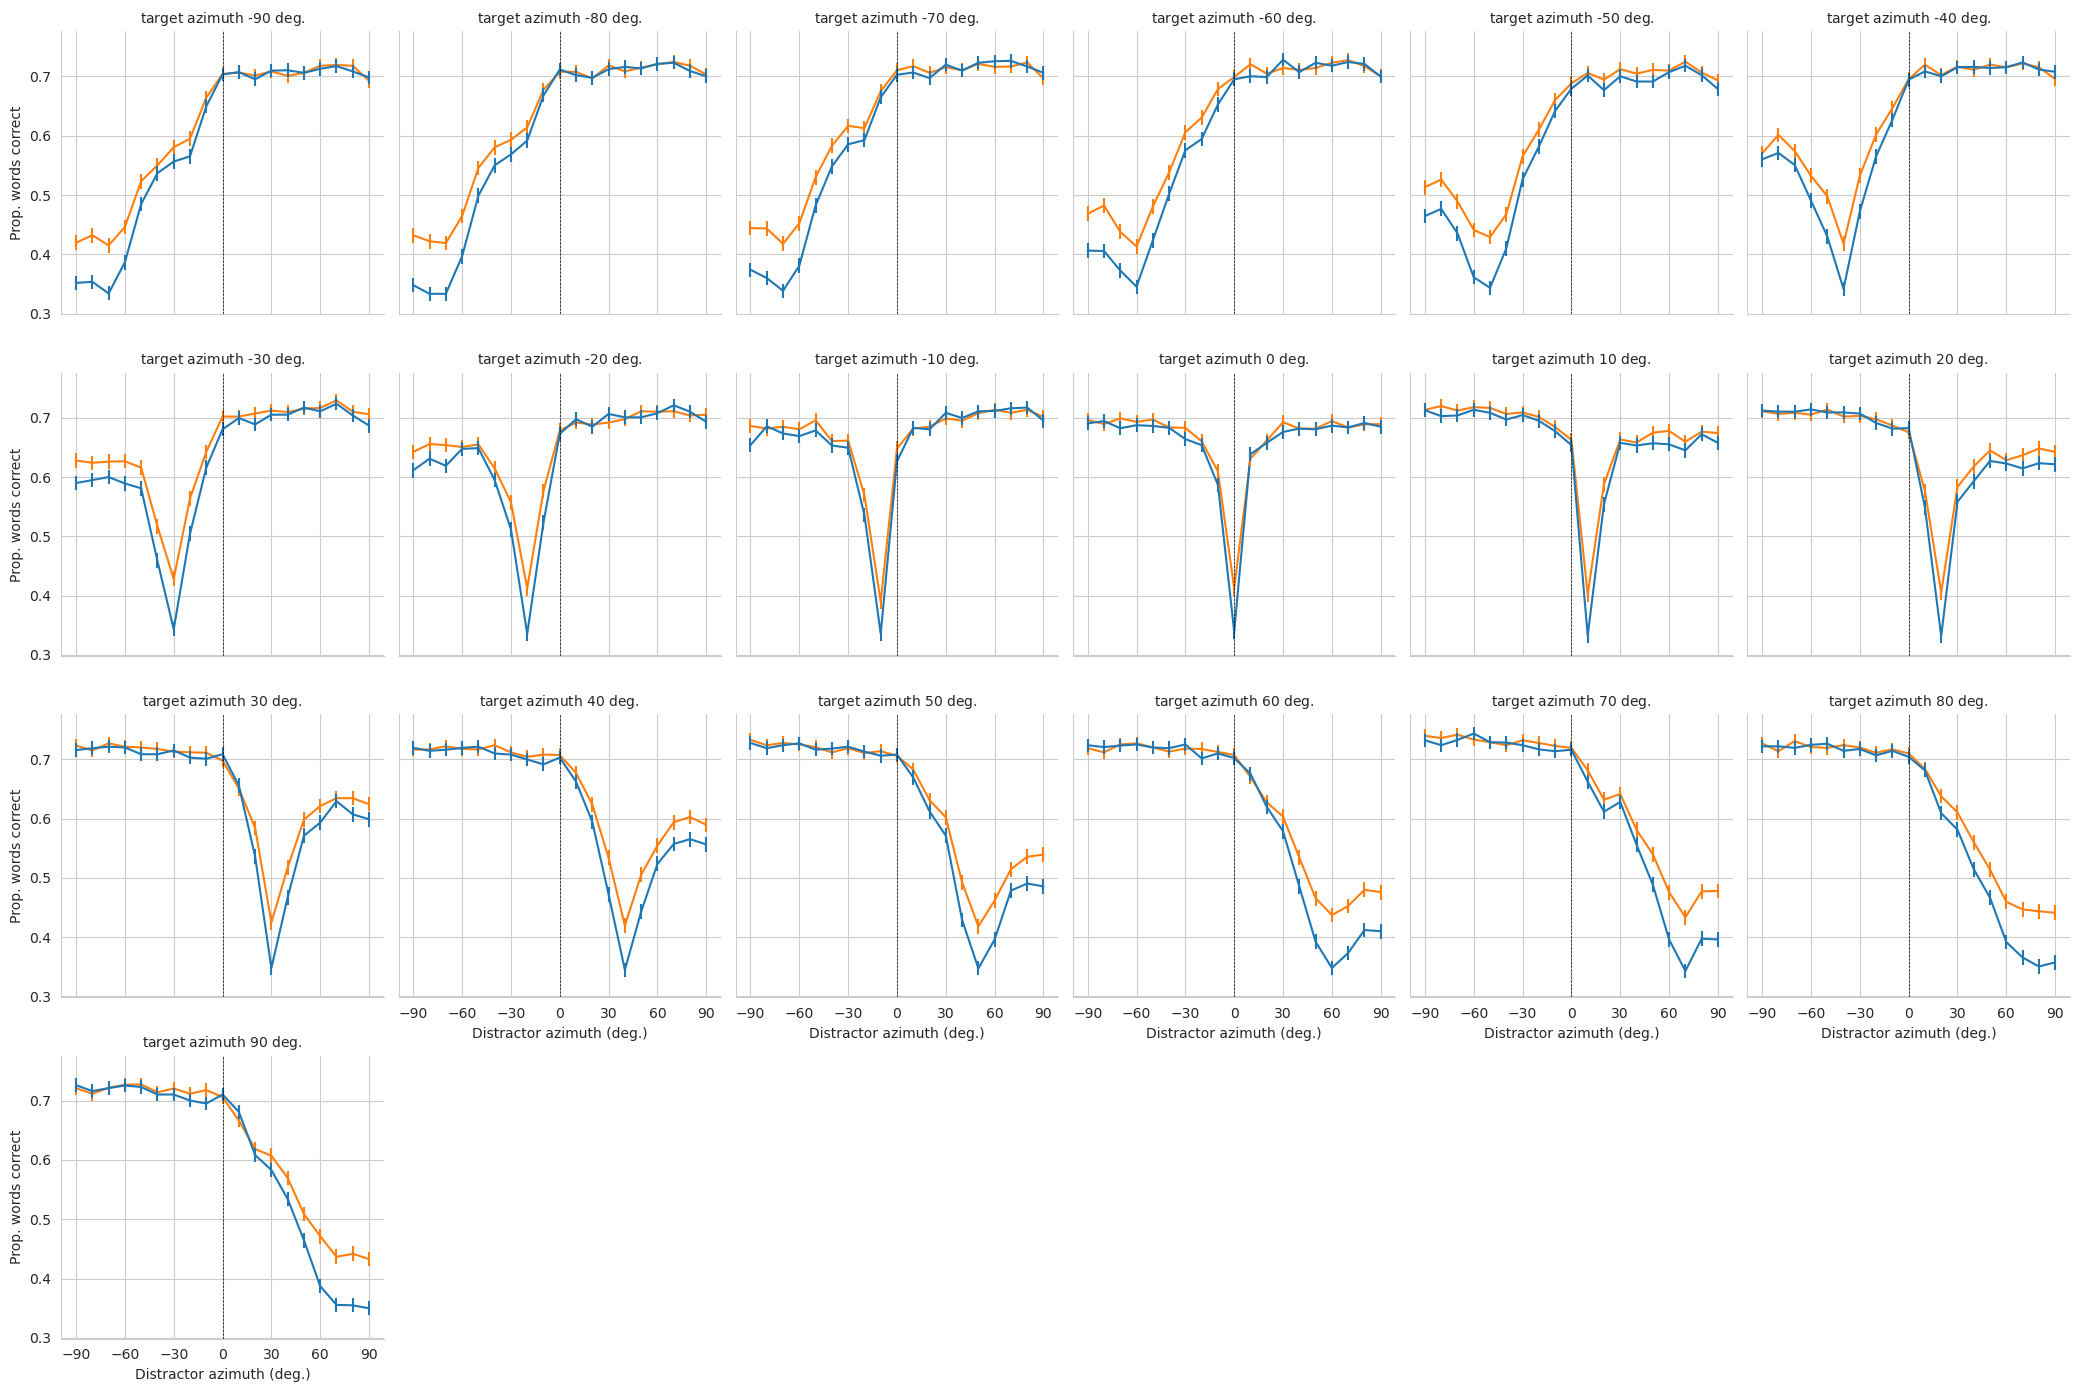

In [27]:

palette = {'same':'tab:blue', 'diff':'tab:orange'}  
sns.set_style('whitegrid')

to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.distractor_elev == 0)]
g = sns.relplot(data=to_plot,
                palette=palette,
                 x='distractor_azim', y='accuracy_mean', 
                 hue='gender_cond', kind='line', 
                 col='target_azim', col_wrap= 6, height=3.5)

# iterate through each facet of the facetgrid
for azim, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    # select the data for the facet
    data = to_plot[to_plot['target_azim'].eq(azim)]
    # select the data for each hue group
    for group, selected in data.groupby('gender_cond'):
        # plot the errorbar with the correct color for each group 
        
        # print(selected)
        ax.errorbar(data=selected, x="distractor_azim", y="accuracy_mean",
                     yerr="accuracy_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. words correct")
g.set_titles("target azimuth {col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

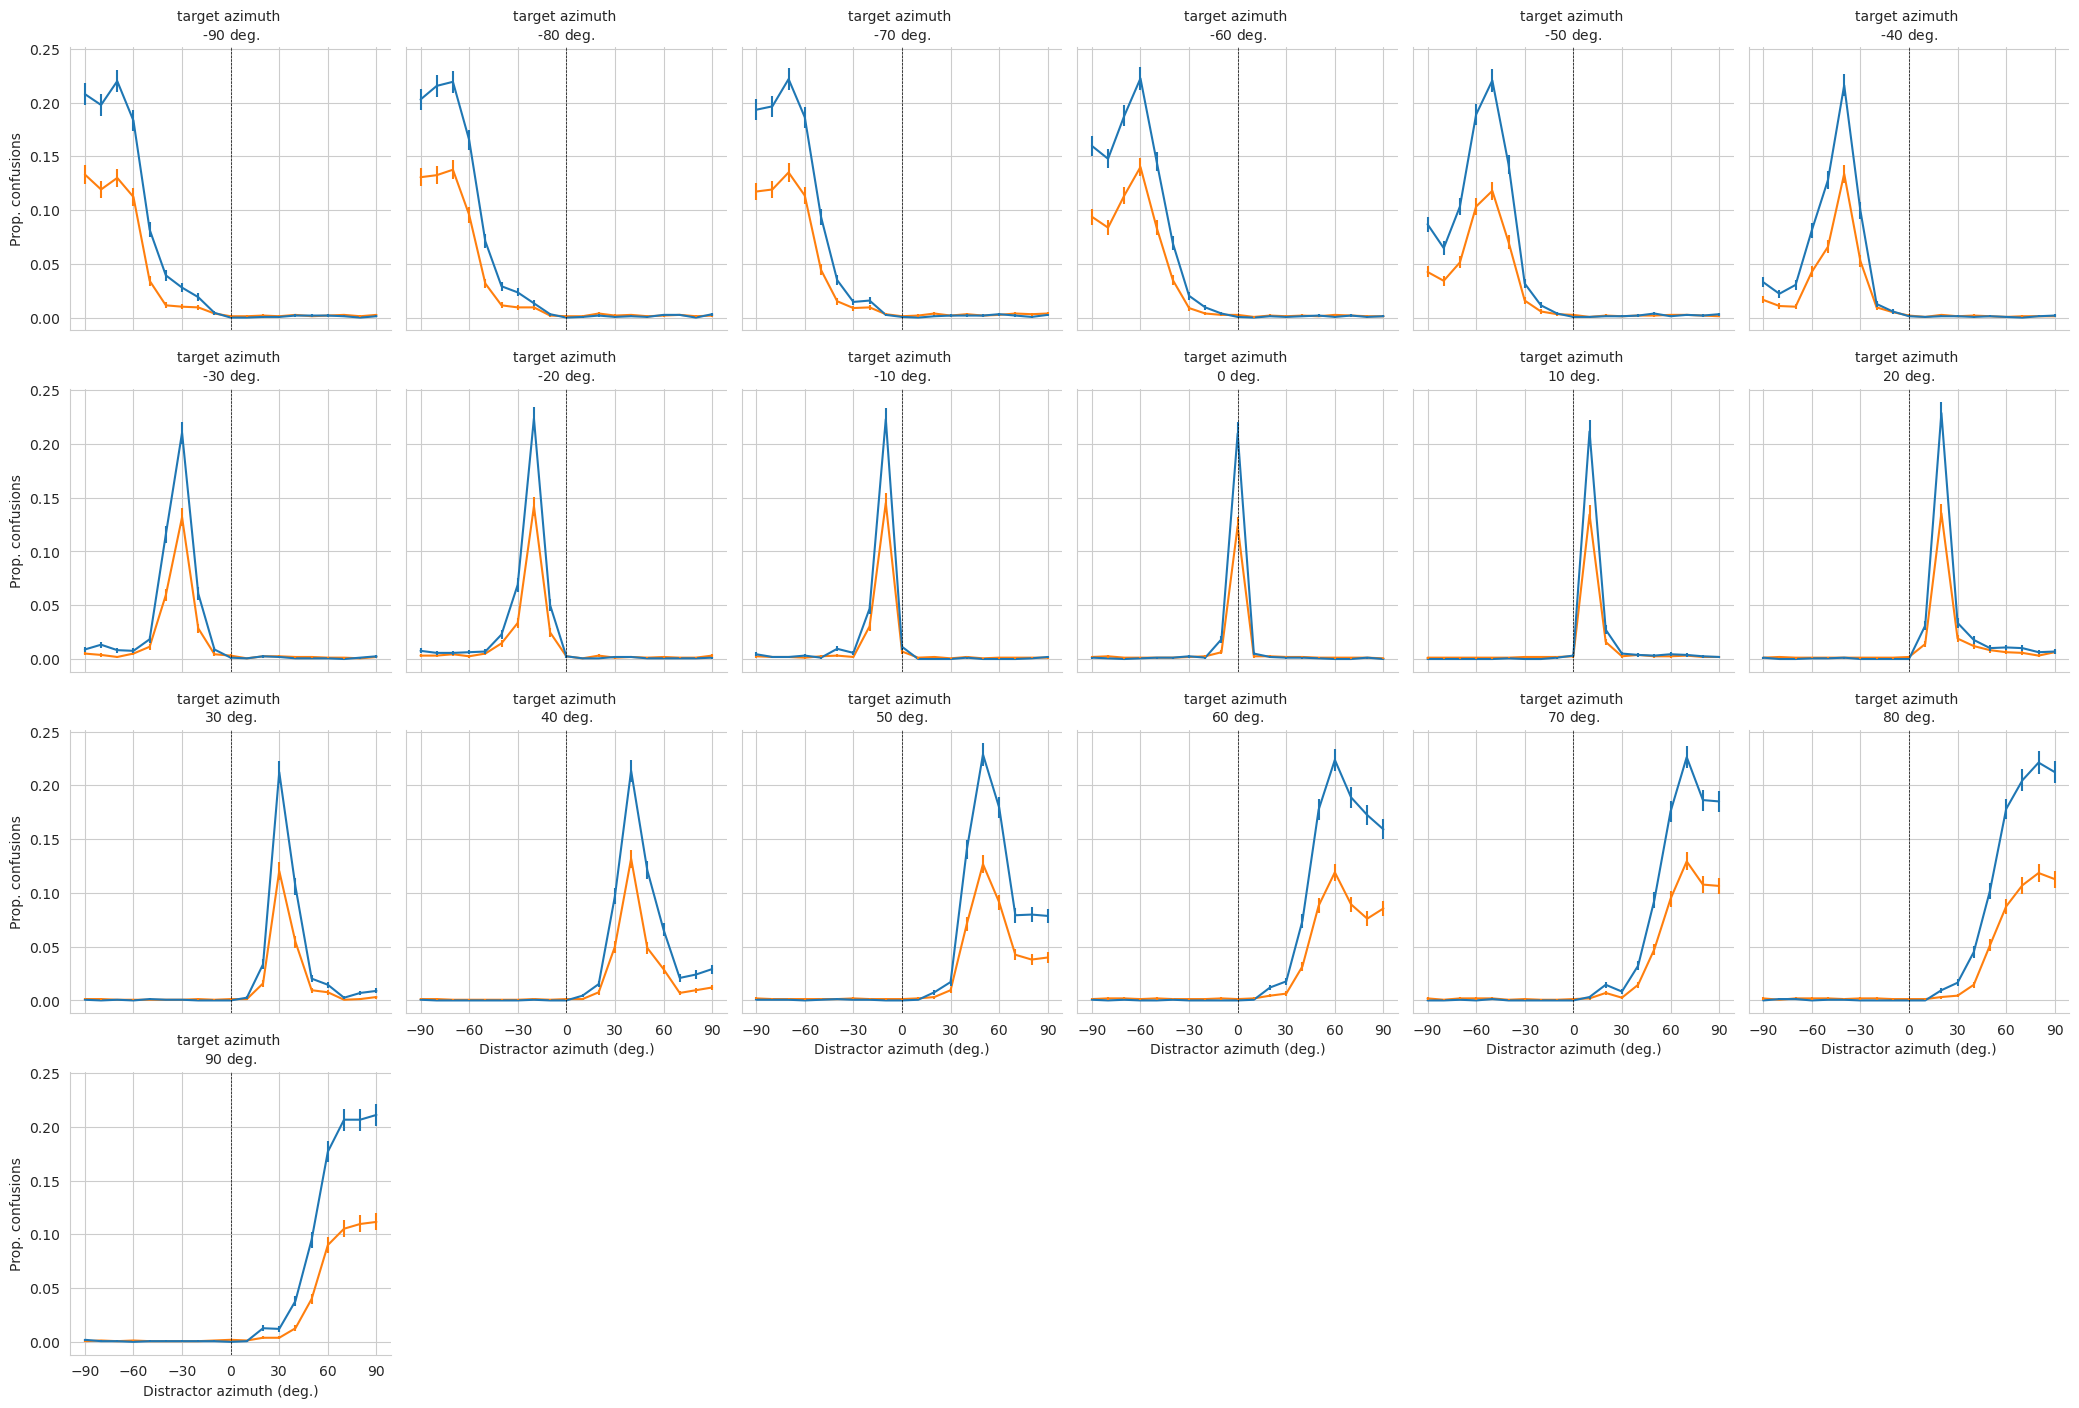

In [28]:

palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = grouped_results[(grouped_results.target_elev == 0)  & (grouped_results.distractor_elev == 0)]
g = sns.relplot(data=to_plot,
                palette=palette,
                 x='distractor_azim', y='confusions_mean', 
                 hue='gender_cond', kind='line', height=3.5,
                 col='target_azim', col_wrap=6)

# iterate through each facet of the facetgrid
for azim, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    # select the data for the facet
    data = to_plot[to_plot['target_azim'].eq(azim)]
    # select the data for each hue group
    for group, selected in data.groupby('gender_cond'):
        # plot the errorbar with the correct color for each group 
        # print(selected)
        ax.errorbar(data=selected, x="distractor_azim", y="confusions_mean",
                     yerr="confusions_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. confusions")
g.set_titles("target azimuth \n{col_name} $\deg.$")
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30))
g.legend.remove()
# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='confusions_mean', hue='gender_cond', kind='line', col='target_azim')

In [29]:
grouped_results.gender_cond.replace({'same':"Same sex", "diff":"Different sex"}, inplace=True)

In [30]:
grouped_results

,target_azim,target_elev,distractor_azim,distractor_elev,gender_cond,accuracy_mean,accuracy_sem,confusions_mean,confusions_sem,elevation_sep,abs_elevation_sep,elevated_source,abs_target_azim,abs_distractor_azim,azim_delta,abs_azim_delta
0,-90,-20,-90,-20,Different sex,0.434728,0.012483,0.129278,0.008449,0,0,co-located,90,90,0,0
1,-90,-20,-90,-20,Same sex,0.363752,0.012114,0.213561,0.010320,0,0,co-located,90,90,0,0
2,-90,-20,-90,-10,Different sex,0.453739,0.012537,0.124208,0.008305,-10,10,distractor,90,90,0,0
3,-90,-20,-90,-10,Same sex,0.378327,0.012212,0.201521,0.010101,-10,10,distractor,90,90,0,0
4,-90,-20,-90,0,Different sex,0.487326,0.012587,0.110266,0.007887,-20,20,distractor,90,90,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,90,40,90,20,Same sex,0.459442,0.012549,0.102662,0.007643,20,20,target,90,90,0,0
1012,90,40,90,30,Different sex,0.509506,0.012589,0.074144,0.006598,10,10,target,90,90,0,0
1013,90,40,90,30,Same sex,0.444867,0.012514,0.128010,0.008413,10,10,target,90,90,0,0
1014,90,40,90,40,Different sex,0.423321,0.012442,0.133714,0.008570,0,0,co-located,90,90,0,0


/tmp/ipykernel_2011691/355712103.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['folded_distractor_azim'] = to_plot.distractor_azim


Text(0.5, 1.05, 'Attentional tuning in azimuth')

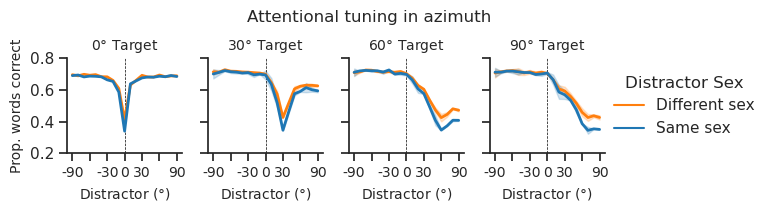

In [31]:
## Make plot with folded azimuths

sns.set_theme(style="ticks")

palette = {'Same sex':'tab:blue', 'Different sex':'tab:orange'}  

to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.abs_target_azim.isin([0,30,60,90])) & (grouped_results.distractor_elev == 0)]
to_plot.target_azim.unique()
to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 
fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=2, zorder=5,
                 x='folded_distractor_azim', y='accuracy_mean', 
                 hue='gender_cond', kind='line', errorbar=('se', 2),
                 col='abs_target_azim', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. words correct", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ Target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0.20, 0.81, 0.2))
xticks, xlabels =  plt.xticks()
g.set_xticklabels([-90,'', -30, 0, 30, '', 90], size = fontsize)

# add x line at 0 
for ax in g.axes.flatten():
    ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# change legend title 
g._legend.set_title('Distractor Sex')
# # change handle titles 
# for t, l in zip(g._legend.texts, ["Same", "Different"]):
#     t.set_text(l)

# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
plt.suptitle('Attentional tuning in azimuth', fontsize=fontsize+2, y=1.05)

# plt.savefig(outfig_dest/'azimuth_tuning.svg', transparent=True, bbox_inches='tight')

In [32]:
to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.abs_target_azim.isin([0,30,60,90])) & (grouped_results.distractor_elev == 0)]

print(f"Max: {grouped_results.accuracy_mean.max()}, Min: {grouped_results.accuracy_mean.min()}")
print(to_plot[(to_plot.target_azim==0) & (to_plot.distractor_azim==90)].accuracy_mean.mean())
print(to_plot[(to_plot.target_azim==0) & (to_plot.distractor_azim==90)].accuracy_mean.mean())
print(to_plot[(to_plot.target_azim==90) & (to_plot.distractor_azim==-90)].accuracy_mean.mean())



Max: 0.7433460076045627, Min: 0.3181242078580482
0.6872623574144487
0.6872623574144487
0.7237008871989861


Text(0.5, 1.05, 'Attentional tuning in elevation')

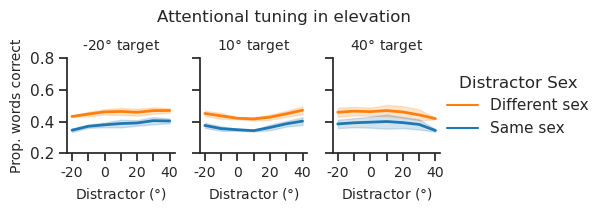

In [34]:
to_plot = grouped_results[(grouped_results.azim_delta == 0) & (grouped_results.abs_target_azim.isin([0,30,90])) & (grouped_results.target_elev != 0 )]
hue_order = ['target', 'distractor', 'co-located']


## Make plot with folded azimuths

sns.set_theme(style="ticks")

palette = {'Same sex':'tab:blue', 'Different sex':'tab:orange'}  

fontsize=10
g = sns.relplot(data=to_plot,
                palette=palette,
                linewidth=2, zorder=5,
                 x='distractor_elev', y='accuracy_mean', 
                 hue='gender_cond', kind='line', errorbar=('se', 2),
                 col='target_elev', height=2, aspect=0.8)

g.set_axis_labels("Distractor ($\degree$)", "Prop. words correct", fontsize=fontsize)
g.set_titles("{col_name}$\degree$ target",size=fontsize)
# set xticks of g from -90 to 90 
g.set(xticks=np.arange(-20, 41, 10), yticks=np.arange(0.20, 0.81, 0.2))
g.set_xticklabels([-20,'', 0, '', 20, '', 40], size = fontsize)

# change legend title 
g._legend.set_title('Distractor Sex')
# change handle titles 
# for t, l in zip(g._legend.texts, ["Same", "Different"]):
#     t.set_text(l)

# xticks, xlabels =  plt.xticks()
# g.set_xticklabels(np.arange(-90, 91, 30), size = fontsize-1)

# add x line at 0 
# plt.suptitle('Chance co-located trials in training', fontsize=fontsize+2, y=1.05)
plt.suptitle('Attentional tuning in elevation', fontsize=fontsize+2, y=1.05)
# plt.savefig(outfig_dest/'elevation_tuning.svg', transparent=True, bbox_inches='tight')


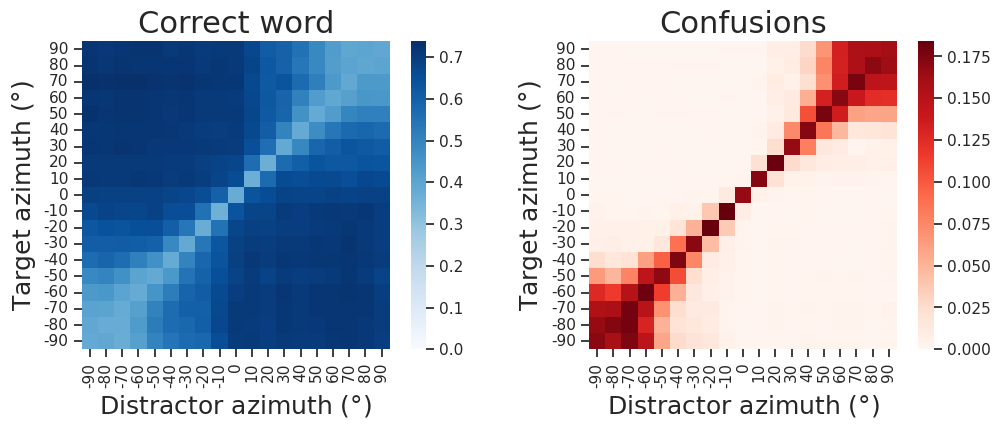

In [35]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions_mean']

fontsize=22
to_plot = grouped_results[grouped_results.target_elev.eq(0) & grouped_results.distractor_elev.eq(0)]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])
# make heatmpas square 
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')

# scale size of  colorbar to match heatmap
cbar_kws = {"shrink": .7,}

total_acc = to_plot.groupby(["target_azim", "distractor_azim"])['accuracy_mean'].mean()
sns.heatmap(total_acc.unstack(), vmin=0, vmax=total_acc.max(), cmap='Blues', cbar=True,ax=axs[0])
total_con = to_plot.groupby(['target_azim', 'distractor_azim'])['confusions_mean'].mean()
sns.heatmap(total_con.unstack(), vmin=0, vmax=total_con.max(), cmap='Reds', cbar=True,  ax=axs[1]) # cbar_kws=cbar_kws,

axs[0].set_title("Correct word", fontsize=fontsize)#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions", fontsize=fontsize) # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# change axis labels for both heatmaps
for ax in axs:
    # ax.set_xticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    # ax.set_yticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    ax.set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize-4)
    ax.set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize-4)

# axs[0].set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize-4)
# axs[0].set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize-4)

# fig.tight_layout(rect=[0,0,.9,1])
# plt.suptitle('50% co-located trials in training', fontsize=14, y=1.05)

# make colorbar match heatmap size

# set confusions colorbar ticks to 0.5 increments
cbar_1 = axs[1].collections[0].colorbar
# cbar_1.set_ticks(np.arange(0, 0.21, 0.05))


for ax in axs.flatten():
    ax.invert_yaxis()

# plt.savefig(outfig_dest/'azim_heatmaps.svg', trasnsparent=True, bbox_inches='tight')

# plt.tight_layout()